## Setup
We import all required libraries and define the downsample factor. 
To manage memory efficiently with large national-scale rasters, all 
rasters are downsampled to 250m resolution (factor of 10) from the 
original 25m, reducing memory usage by 100x while preserving spatial 
patterns at national scale.

In [1]:
import geopandas as gpd
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Patch
from matplotlib.colors import LinearSegmentedColormap
from rasterio.plot import show
from rasterio.warp import reproject, Resampling
from rasterio.mask import mask as rasterio_mask
from rasterio.features import rasterize
from shapely.geometry import mapping, box
import pandas as pd
import os
import gc

# Downsample factor — 10 means 25m → 250m resolution
FACTOR = 10

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Load Data
### 1.1 Load Portugal Boundary

In [2]:
world = gpd.read_file("../data/raw/portugal_boundaries/ne_10m_admin_0_countries_prt.shp").to_crs("EPSG:3763")
portugal = world[world["ADMIN"] == "Portugal"]
mainland_bbox = box(-150000, -350000, 150000, 350000)
portugal_mainland = portugal.clip(mainland_bbox)
print("Portugal boundary loaded:", portugal_mainland.shape)

Portugal boundary loaded: (1, 169)


### 1.2 Load Vector Datasets
We load all vector layers needed for the risk model: burned area perimeters 
for each year, critical fire locations, vegetation index, aridity index 
and the primary fuel management network.

In [3]:
# Burned areas per year
burned_2021 = gpd.read_file("../data/raw/burned_areas/burned_2021/ardida_2021.shp")
burned_2022 = gpd.read_file("../data/raw/burned_areas/burned_2022/ardida_2022.shp")
burned_2023 = gpd.read_file("../data/raw/burned_areas/burned_2023/ardida_2023.shp")
burned_2024 = gpd.read_file("../data/raw/burned_areas/burned_2024/ardida_2024.shp")

# Other risk factor layers
critical_locations = gpd.read_file("../data/raw/critical_fire_locations/critical_location.shp")
vegetation = gpd.read_file("../data/raw/vegetation_index/iqv_2000.shp")
aridity = gpd.read_file("../data/raw/aridity_index/aridity_index_2000_2010.shp")
fuel_network = gpd.read_file("../data/raw/primary_fuel_management_network/primary_network.shp")

print("Burned areas 2021:", burned_2021.shape)
print("Burned areas 2022:", burned_2022.shape)
print("Burned areas 2023:", burned_2023.shape)
print("Burned areas 2024:", burned_2024.shape)
print("Critical locations:", critical_locations.shape)
print("Vegetation:", vegetation.shape)
print("Aridity:", aridity.shape)
print("Fuel network:", fuel_network.shape)

Burned areas 2021: (918, 23)
Burned areas 2022: (1786, 24)
Burned areas 2023: (1736, 24)
Burned areas 2024: (1558, 23)
Critical locations: (8265, 23)
Vegetation: (6, 4)
Aridity: (674, 4)
Fuel network: (5529, 11)


### 1.3 Load Hazard Rasters
We load each annual hazard raster at 250m resolution immediately to save memory.

In [4]:
hazard_paths = {
    2021: "../data/raw/conjunctural_hazard_maps/conjunctural_hazard_2021/perigosidade_conjuntural_2021.tif",
    2022: "../data/raw/conjunctural_hazard_maps/conjunctural_hazard_2022/perigosidade_conjuntural_2022.tif",
    2023: "../data/raw/conjunctural_hazard_maps/conjunctural_hazard_2023/perigosidade_conjuntural2023.tif",
    2024: "../data/raw/conjunctural_hazard_maps/conjunctural_hazard_2024/PerigosidadeConjuntural_2024/perigosidade_conjuntural2024.tif",
}
nodata_values = {2021: 255, 2022: None, 2023: 15, 2024: 15}

# Get reference grid at 250m resolution
with rasterio.open(hazard_paths[2021]) as ref:
    ref_height = ref.height // FACTOR
    ref_width = ref.width // FACTOR
    ref_transform = ref.transform * ref.transform.scale(
        ref.width / ref_width,
        ref.height / ref_height
    )
    ref_crs = ref.crs
    ref_shape = (ref_height, ref_width)

print("Reference grid shape:", ref_shape)
print("Reference CRS:", ref_crs)

Reference grid shape: (2306, 1125)
Reference CRS: EPSG:3763


### 1.2 Create Portugal Mainland Mask
We create a raster mask of mainland Portugal to clip all raster 
visualisations to the country boundary.

In [5]:
from rasterio.features import geometry_mask
from shapely.geometry import mapping

portugal_geom = [mapping(geom) for geom in portugal_mainland.geometry]

port_mask = geometry_mask(
    portugal_geom,
    out_shape=ref_shape,
    transform=ref_transform,
    invert=True
)

print("Portugal mask created:", port_mask.shape)
print("Pixels inside Portugal:", port_mask.sum())

Portugal mask created: (2306, 1125)
Pixels inside Portugal: 1414222


## 2. Data Preparation
### 2.1 Merge Burned Areas and Prepare Vector Layers
We merge the four annual burned area layers into a single cumulative 
layer and convert categorical variables to numerical values for 
use in the risk model.

In [6]:
# Merge burned areas
cols = ["geometry"]
burned_all = pd.concat([
    burned_2021[cols], burned_2022[cols],
    burned_2023[cols], burned_2024[cols]
]).reset_index(drop=True)

print("Total fire perimeters:", len(burned_all))

# Convert vegetation categories to numerical values
vegetation_map = {
    'NoData': np.nan, 'Baixa': 1, 'Média': 2,
    'Moderada': 3, 'Alta': 4, 'Muito alta': 5
}
aridity_map = {
    'Humido': 1, 'Subhumido Humido': 2,
    'Subhumido Seco': 3, 'Semiarido': 4
}

vegetation["iqv_num"] = vegetation["iqv"].map(vegetation_map)
aridity["indaride_num"] = aridity["indaride"].map(aridity_map)

print("Vegetation values:", vegetation["iqv_num"].unique())
print("Aridity values:", aridity["indaride_num"].unique())

Total fire perimeters: 5998
Vegetation values: [nan  2.  3.  4.  5.  1.]
Aridity values: [nan  2.  1.  3.  4.]


### 2.2 Load and Normalise Hazard Rasters
We load each annual hazard raster at 250m resolution and normalise 
them to a 0-1 scale before averaging. Normalisation is necessary 
because the four years use different original scales (0-255, 0-5, 0-15), 
which would bias the average if used directly.

In [7]:
hazard_arrays = []

for year, path in hazard_paths.items():
    with rasterio.open(path) as src:
        # Load at 250m resolution
        data = src.read(1, out_shape=ref_shape).astype("float32")
        
        # Mask nodata and zeros
        nd = nodata_values[year]
        if nd is not None:
            data[data == nd] = np.nan
        data[data == 0] = np.nan
        
        # Normalise to 0-1
        data_min = np.nanmin(data)
        data_max = np.nanmax(data)
        data = (data - data_min) / (data_max - data_min)
        hazard_arrays.append(data)

# Average across four years
hazard_mean = np.nanmean(np.stack(hazard_arrays, axis=0), axis=0)

print("Hazard mean shape:", hazard_mean.shape)
print("Hazard mean range:", np.nanmin(hazard_mean), "-", np.nanmax(hazard_mean))

Hazard mean shape: (2306, 1125)
Hazard mean range: 0.0 - 1.0


C:\Users\marta\AppData\Local\Temp\ipykernel_11216\3147644479.py:21: RuntimeWarning: Mean of empty slice
  hazard_mean = np.nanmean(np.stack(hazard_arrays, axis=0), axis=0)


### 2.3 Rasterise Vector Layers
We convert all vector layers to raster format at 250m resolution 
using the hazard layer as the reference grid.

In [8]:
portugal_geom = [mapping(geom) for geom in portugal_mainland.geometry]

# Burned areas — binary (burned=1, not burned=0)
burned_geoms = [(geom, 1) for geom in burned_all.geometry if geom is not None]
burned_raster = rasterize(
    burned_geoms, out_shape=ref_shape,
    transform=ref_transform, fill=0, dtype="float32"
)

# Critical locations — use NivelCriti as value
critical_geoms = [(geom, val) for geom, val in
                  zip(critical_locations.geometry, critical_locations["NivelCriti"])
                  if geom is not None]
critical_raster = rasterize(
    critical_geoms, out_shape=ref_shape,
    transform=ref_transform, fill=0, dtype="float32"
)

# Vegetation — use iqv_num as value
veg_geoms = [(geom, val) for geom, val in
             zip(vegetation.geometry, vegetation["iqv_num"])
             if geom is not None and not np.isnan(val)]
veg_raster = rasterize(
    veg_geoms, out_shape=ref_shape,
    transform=ref_transform, fill=0, dtype="float32"
)

# Aridity — use indaride_num as value
arid_geoms = [(geom, val) for geom, val in
              zip(aridity.geometry, aridity["indaride_num"])
              if geom is not None and not np.isnan(val)]
arid_raster = rasterize(
    arid_geoms, out_shape=ref_shape,
    transform=ref_transform, fill=0, dtype="float32"
)

print("Burned range:", burned_raster.min(), "-", burned_raster.max())
print("Critical range:", critical_raster.min(), "-", critical_raster.max())
print("Vegetation range:", veg_raster.min(), "-", veg_raster.max())
print("Aridity range:", arid_raster.min(), "-", arid_raster.max())

Burned range: 0.0 - 1.0
Critical range: 0.0 - 25.9366
Vegetation range: 0.0 - 5.0
Aridity range: 0.0 - 4.0


### 2.4 Normalise to 1–5 Scale and Apply Weighted Overlay
We normalise all layers to a common 1–5 scale and combine them using 
the weighted formula. Zeros are treated as nodata and excluded from 
the calculation. The weight sum is tracked per pixel so that missing 
layers do not bias the result.

**Risk = 0.35 × Conjunctural Hazard + 0.20 × Critical Locations + 0.20 × Burned Areas + 0.15 × Vegetation + 0.10 × Aridity**

In [9]:
def normalise_1_5(arr, binary=False):
    """Normalise array to 1-5 scale, treating 0 as nodata."""
    out = np.full(arr.shape, np.nan, dtype="float32")
    if binary:
        # burned = 5, not burned = 1
        out[arr == 1] = 5
        out[arr == 0] = 1
    else:
        mask = arr > 0
        if mask.sum() > 0:
            mn, mx = arr[mask].min(), arr[mask].max()
            if mx > mn:
                out[mask] = 1 + (arr[mask] - mn) / (mx - mn) * 4
            else:
                out[mask] = 1
        out[~mask] = np.nan
    return out

# Normalise each layer
hazard_1_5  = np.where(hazard_mean > 0, 1 + hazard_mean * 4, np.nan).astype("float32")
burned_1_5  = normalise_1_5(burned_raster, binary=True)
critical_1_5 = normalise_1_5(critical_raster)
veg_1_5     = normalise_1_5(veg_raster)
arid_1_5    = normalise_1_5(arid_raster)

# Free raw rasters from memory
del burned_raster, critical_raster, veg_raster, arid_raster
gc.collect()

# Weighted overlay — track weight sum per pixel to handle nodata
weights = {"hazard": 0.35, "critical": 0.20, "burned": 0.20, "veg": 0.15, "arid": 0.10}
layers  = {"hazard": hazard_1_5, "critical": critical_1_5,
           "burned": burned_1_5, "veg": veg_1_5, "arid": arid_1_5}

risk_model  = np.zeros(ref_shape, dtype="float32")
weight_sum  = np.zeros(ref_shape, dtype="float32")

for name, layer in layers.items():
    w = weights[name]
    mask = ~np.isnan(layer)
    risk_model[mask] += layer[mask] * w
    weight_sum[mask] += w

risk_model = np.where(weight_sum > 0, risk_model / weight_sum, np.nan)

print("Risk model range:", np.nanmin(risk_model), "-", np.nanmax(risk_model))
print("Risk model shape:", risk_model.shape)

Risk model range: 1.0 - 5.0
Risk model shape: (2306, 1125)


### 2.5. Load Municipality Boundaries
We load the official municipality boundaries for mainland Portugal. 
This layer is essential for the municipal-level analysis — it allows 
us to calculate coverage gaps and vulnerability scores per municipality 
and identify which territories are most at risk and least protected.

In [10]:
municipalities = gpd.read_file("../data/raw/municipalities/concelhos_Project.shp")
print(municipalities.shape)
print(municipalities.crs)
print(municipalities.columns.tolist())
print(municipalities.head())

(281, 3)
EPSG:3763
['ObjectID', 'NAME', 'geometry']
   ObjectID           NAME                                           geometry
0        94        Setúbal  POLYGON ((-77793.528 -120594.573, -77605.067 -...
1        95  Vila Do Bispo  POLYGON ((-56876.481 -288057.984, -56957.02 -2...
2        96       Sesimbra  POLYGON ((-78862.629 -120548.788, -78716.522 -...
3       104          Moura  POLYGON ((86129.19 -167278.897, 86122.452 -167...
4       105         Tavira  POLYGON ((44589.473 -264189.183, 45191.197 -26...


## 3. Exploratory Analysis
### 3.1 Cumulative Burned Areas Map
We plot all burned area perimeters for the study period (2021–2024), 
with each year shown in a different colour to highlight temporal patterns.

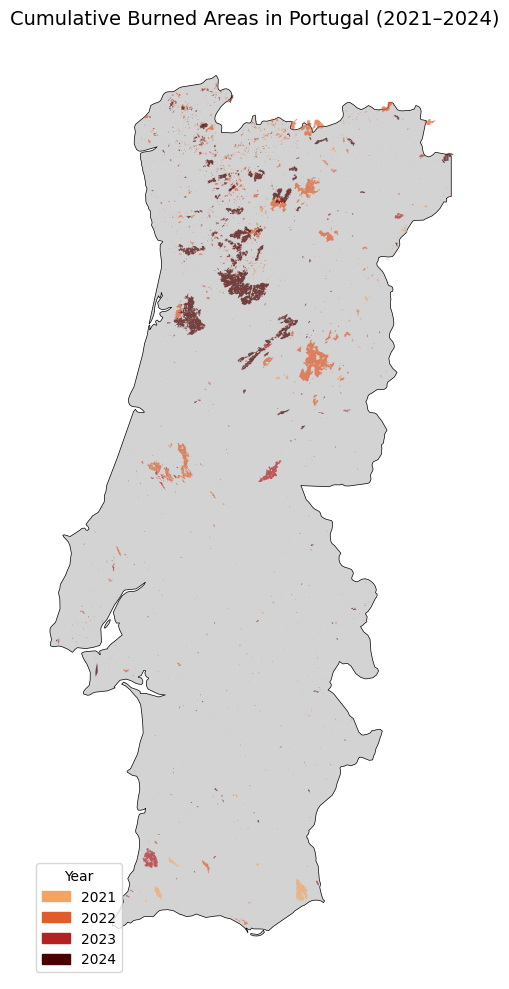

In [11]:
import matplotlib.patches as mpatches

# Add year column to each
burned_2021["year"] = 2021
burned_2022["year"] = 2022
burned_2023["year"] = 2023
burned_2024["year"] = 2024

cols = ["year", "geometry"]
burned_all_plot = pd.concat([
    burned_2021[cols], burned_2022[cols],
    burned_2023[cols], burned_2024[cols]
]).reset_index(drop=True)

colors = {2021: "#f4a460", 2022: "#e05c2a", 2023: "#b22222", 2024: "#4a0000"}

fig, ax = plt.subplots(figsize=(8, 10))
portugal_mainland.plot(ax=ax, color="lightgrey", edgecolor="black", linewidth=0.5)

for year, color in colors.items():
    burned_all_plot[burned_all_plot["year"] == year].plot(
        ax=ax, color=color, edgecolor="none", alpha=0.7
    )

patches = [mpatches.Patch(color=c, label=str(y)) for y, c in colors.items()]
ax.legend(handles=patches, title="Year", loc="lower left")
ax.set_title("Cumulative Burned Areas in Portugal (2021–2024)", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("../outputs/burned_areas_2021_2024.png", dpi=150)
plt.show()

### 3.2 Total Burned Area per Year
We calculate and visualise the total burned area in hectares for each 
year to highlight which years were most destructive.

   year  total_area_ha
0  2021   27374.628894
1  2022  115148.600723
2  2023   34151.106022
3  2024  139396.848847


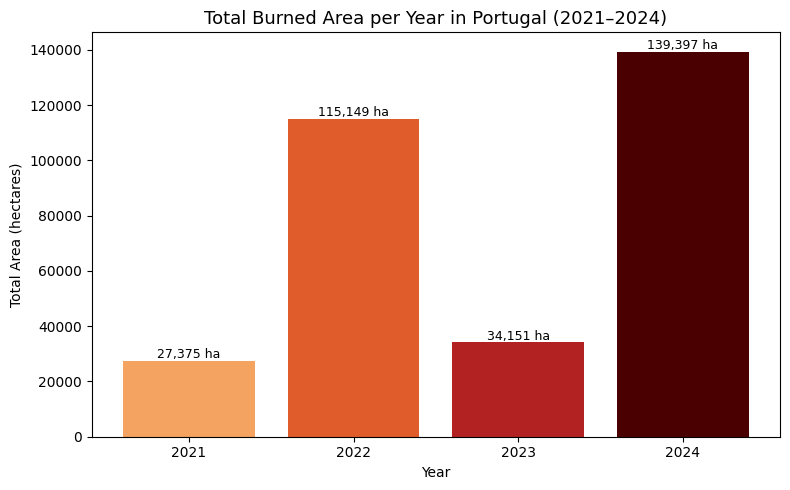

In [12]:
burned_all_plot["area_ha"] = burned_all_plot.geometry.area / 10000

summary = burned_all_plot.groupby("year")["area_ha"].sum().reset_index()
summary.columns = ["year", "total_area_ha"]

print(summary)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(summary["year"], summary["total_area_ha"],
       color=["#f4a460", "#e05c2a", "#b22222", "#4a0000"])
ax.set_title("Total Burned Area per Year in Portugal (2021–2024)", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("Total Area (hectares)")
ax.set_xticks([2021, 2022, 2023, 2024])
for i, row in summary.iterrows():
    ax.text(row["year"], row["total_area_ha"] + 1000, 
            f"{row['total_area_ha']:,.0f} ha", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("../outputs/burned_area_per_year.png", dpi=150)
plt.show()

### 3.3 Burned Areas by Year
We plot each year separately to visualise how the spatial distribution 
of fires shifted across the study period.

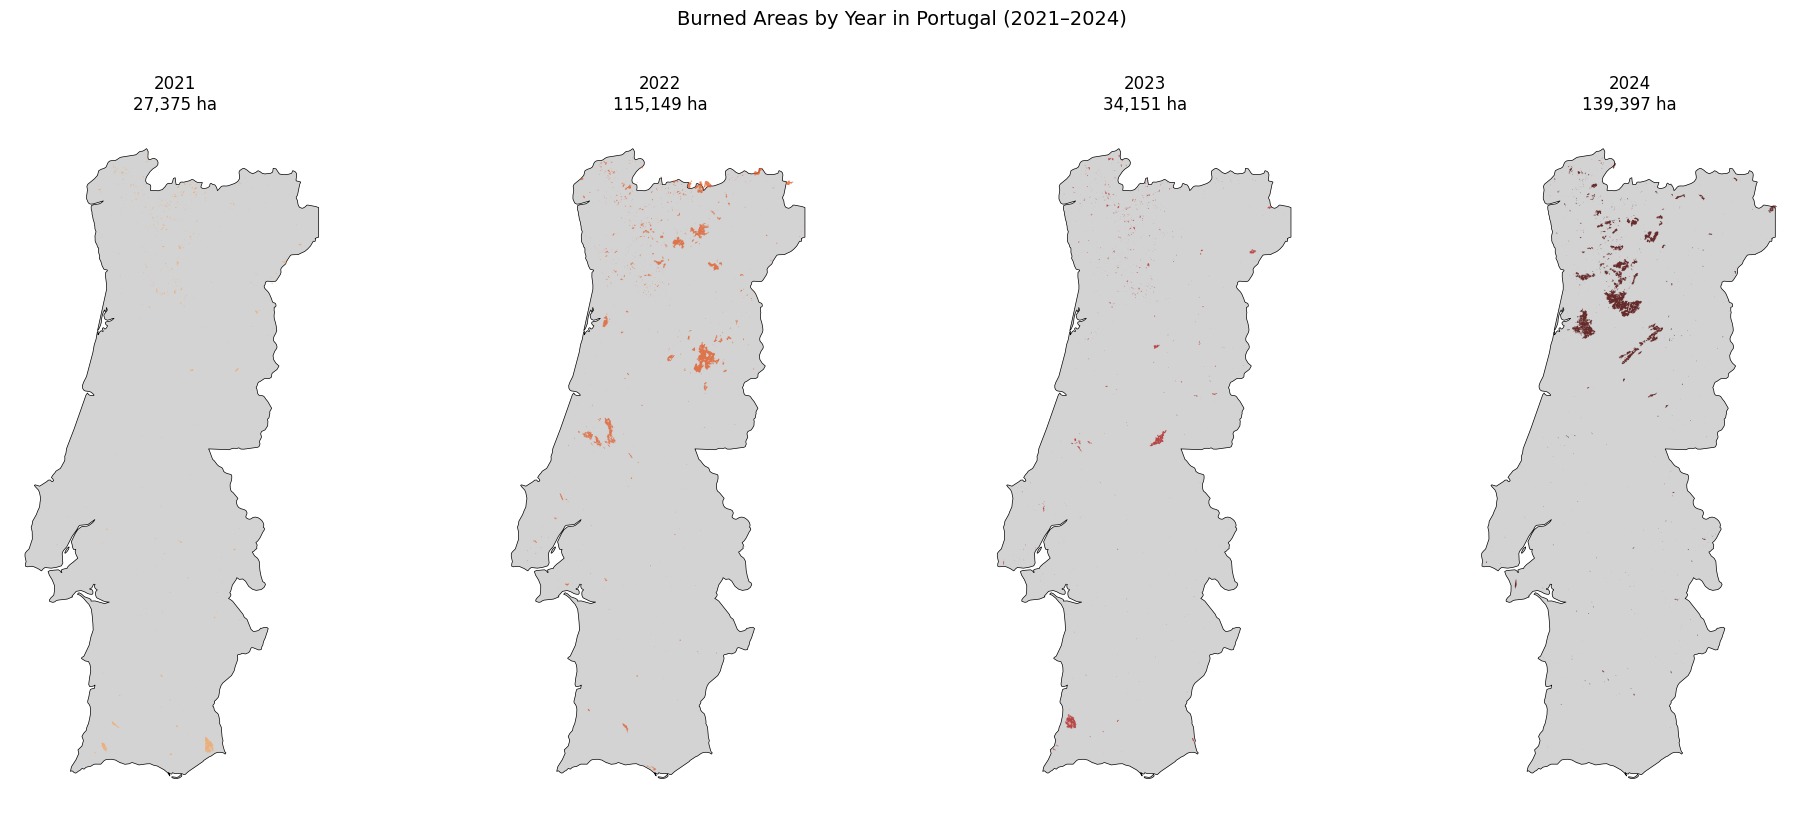

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(20, 8))

for ax, (year, color) in zip(axes, colors.items()):
    portugal_mainland.plot(ax=ax, color="lightgrey", edgecolor="black", linewidth=0.5)
    burned_all_plot[burned_all_plot["year"] == year].plot(
        ax=ax, color=color, edgecolor="none", alpha=0.8
    )
    total = summary[summary["year"] == year]["total_area_ha"].values[0]
    ax.set_title(f"{year}\n{total:,.0f} ha", fontsize=12)
    ax.set_axis_off()

plt.suptitle("Burned Areas by Year in Portugal (2021–2024)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../outputs/burned_areas_by_year.png", dpi=150, bbox_inches="tight")
plt.show()

### 3.4 Conjunctural Hazard by Year
We plot each year's hazard raster normalised to a 0-1 scale to visualise 
how climate-driven fire danger conditions varied spatially across the 
study period.

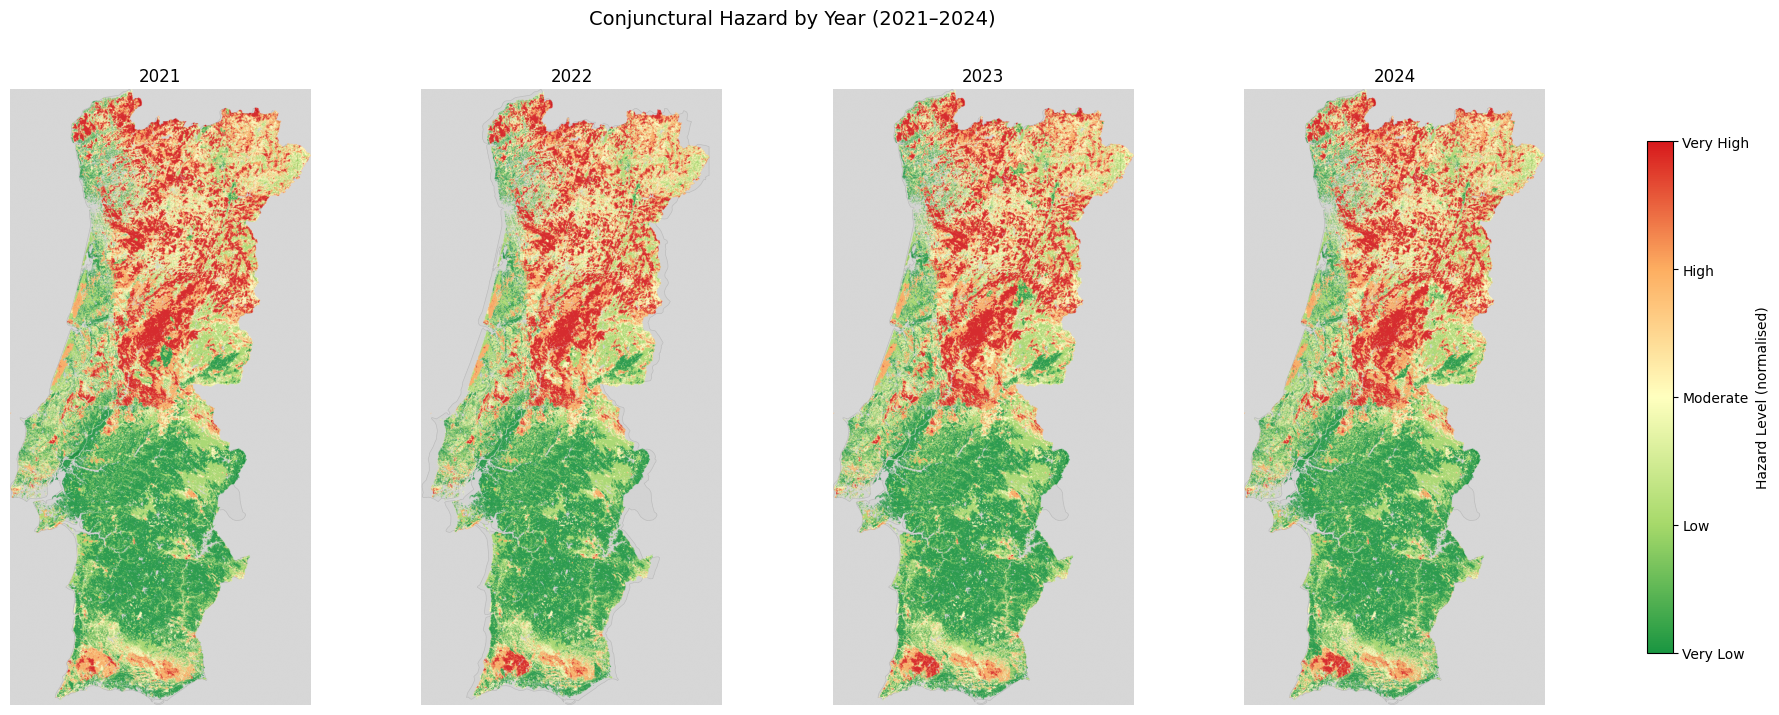

In [14]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

fig, axes = plt.subplots(1, 4, figsize=(22, 8))
colors_ramp = ["#1a9641", "#a6d96a", "#ffffbf", "#fdae61", "#d7191c"]
cmap_hazard = LinearSegmentedColormap.from_list("hazard", colors_ramp)
cmap_hazard.set_bad(color="lightgrey")

for ax, (year, path) in zip(axes, hazard_paths.items()):
    with rasterio.open(path) as src:
        data = src.read(1, out_shape=ref_shape).astype("float32")
        nd = nodata_values[year]
        if nd is not None:
            data[data == nd] = np.nan
        data[data == 0] = np.nan
        data_min = np.nanmin(data)
        data_max = np.nanmax(data)
        data = (data - data_min) / (data_max - data_min)

    portugal_mainland.plot(ax=ax, color="lightgrey", edgecolor="black", linewidth=0.5, zorder=1)
    show(data, transform=ref_transform, ax=ax, cmap=cmap_hazard, zorder=2, alpha=0.9)
    ax.set_title(f"{year}", fontsize=12)
    ax.set_axis_off()

sm = ScalarMappable(cmap=cmap_hazard, norm=Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, fraction=0.015, pad=0.06)
cbar.set_label("Hazard Level (normalised)", fontsize=10)
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
cbar.set_ticklabels(["Very Low", "Low", "Moderate", "High", "Very High"])

plt.suptitle("Conjunctural Hazard by Year (2021–2024)", fontsize=14)
plt.savefig("../outputs/hazard_by_year.png", dpi=150, bbox_inches="tight")
plt.show()

### 3.5 Mean Conjunctural Hazard (2021–2024)
We plot the averaged normalised hazard layer that captures the overall 
climate-driven fire danger across the study period.

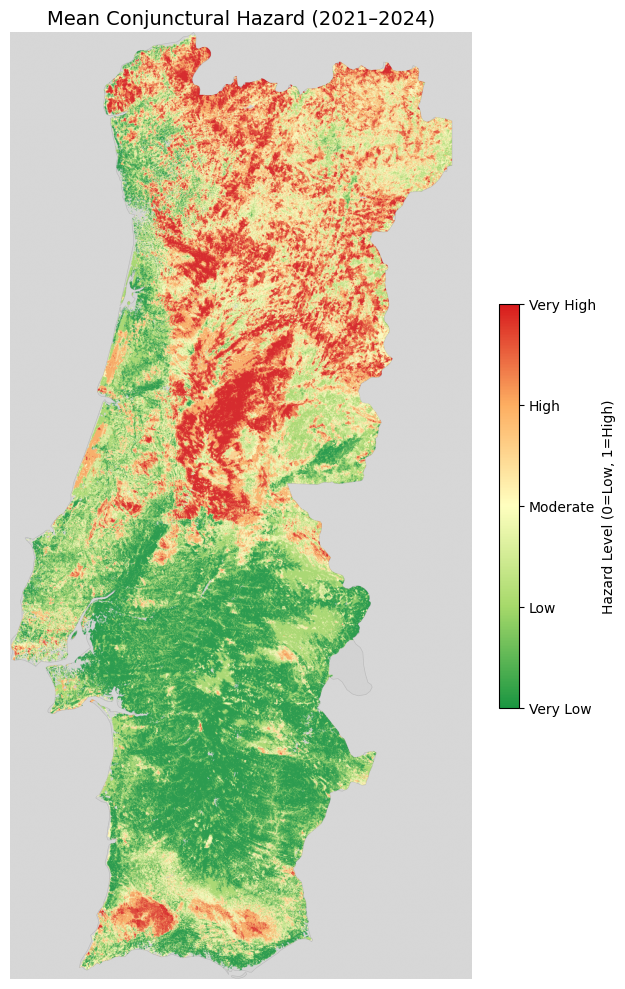

In [15]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

colors_ramp = ["#1a9641", "#a6d96a", "#ffffbf", "#fdae61", "#d7191c"]
cmap_hazard = LinearSegmentedColormap.from_list("hazard", colors_ramp)
cmap_hazard.set_bad(color="lightgrey")

hazard_display = np.where(port_mask, hazard_mean, np.nan)

fig, ax = plt.subplots(figsize=(8, 10))
portugal_mainland.plot(ax=ax, color="lightgrey", edgecolor="black", linewidth=0.5, zorder=1)
show(hazard_display, transform=ref_transform, ax=ax, cmap=cmap_hazard, zorder=2, alpha=0.9)

# Add colorbar legend
sm = ScalarMappable(cmap=cmap_hazard, norm=Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.04)
cbar.set_label("Hazard Level (0=Low, 1=High)", fontsize=10)
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
cbar.set_ticklabels(["Very Low", "Low", "Moderate", "High", "Very High"])

ax.set_title("Mean Conjunctural Hazard (2021–2024)", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("../outputs/mean_hazard.png", dpi=150)
plt.show()

### 3.6 Vegetation Index
We plot the vegetation density index across mainland Portugal. Higher 
values indicate denser vegetation and greater fuel availability for fires.

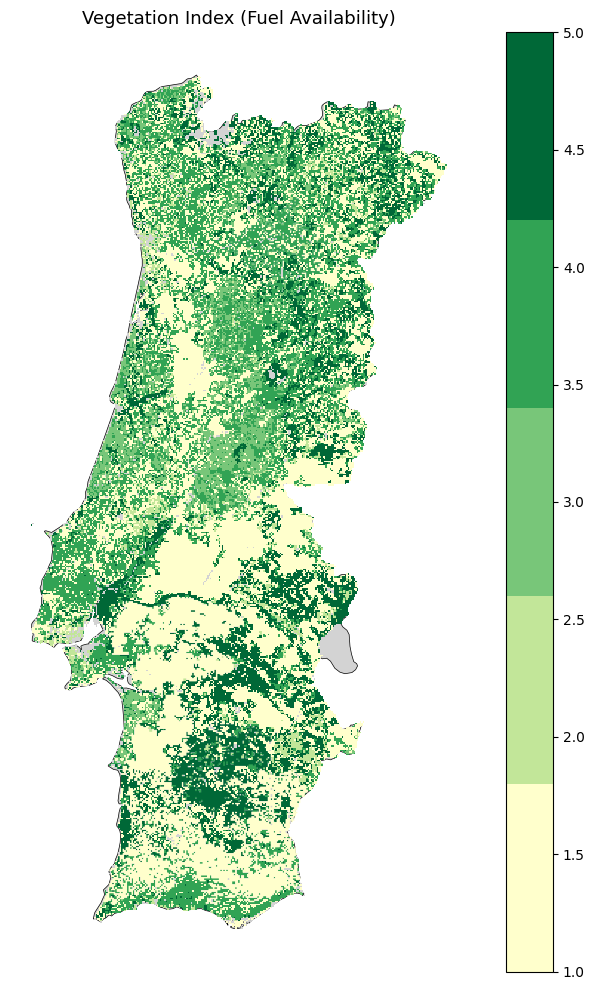

In [16]:
colors_veg = ["#ffffcc", "#c2e699", "#78c679", "#31a354", "#006837"]
cmap_veg = LinearSegmentedColormap.from_list("veg", colors_veg, N=5)

fig, ax = plt.subplots(figsize=(8, 10))
portugal_mainland.plot(ax=ax, color="lightgrey", edgecolor="black", linewidth=0.5)
vegetation.plot(ax=ax, column="iqv_num", cmap=cmap_veg,
                legend=True, missing_kwds={"color": "lightgrey"})
ax.set_title("Vegetation Index (Fuel Availability)", fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("../outputs/vegetation_index.png", dpi=150)
plt.show()

### 3.7 Aridity Index
We plot the aridity index across mainland Portugal. Higher values indicate 
drier conditions which increase fuel desiccation and fire susceptibility.

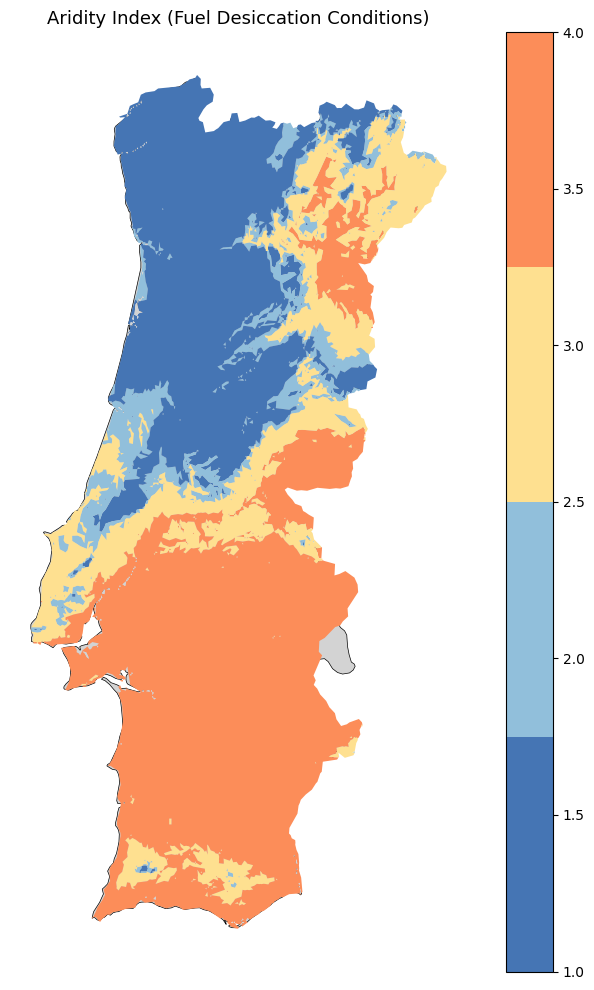

In [17]:
colors_arid = ["#4575b4", "#91bfdb", "#fee090", "#fc8d59"]
cmap_arid = LinearSegmentedColormap.from_list("arid", colors_arid, N=4)

fig, ax = plt.subplots(figsize=(8, 10))
portugal_mainland.plot(ax=ax, color="lightgrey", edgecolor="black", linewidth=0.5)
aridity.plot(ax=ax, column="indaride_num", cmap=cmap_arid,
             legend=True, missing_kwds={"color": "lightgrey"})
ax.set_title("Aridity Index (Fuel Desiccation Conditions)", fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("../outputs/aridity_index.png", dpi=150)
plt.show()

### 3.8 Critical Fire Locations
We plot the structurally fire-prone locations across mainland Portugal. 
These are areas characterised by high fuel continuity, difficult access 
and poor forest management that represent persistent territorial risk 
independent of annual climate conditions.

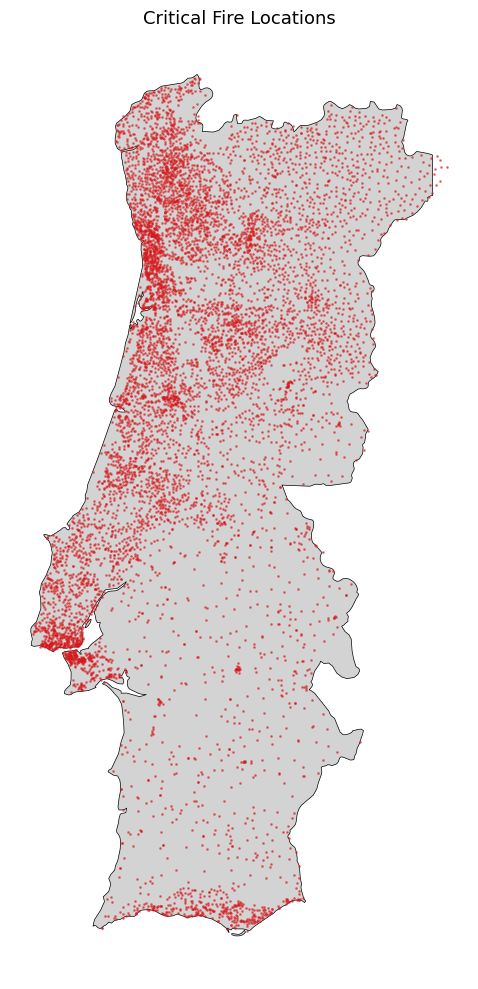

In [18]:
fig, ax = plt.subplots(figsize=(8, 10))
portugal_mainland.plot(ax=ax, color="lightgrey", edgecolor="black", linewidth=0.5)
critical_locations.plot(ax=ax, color="#d7191c", markersize=1, alpha=0.5)
ax.set_title("Critical Fire Locations", fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("../outputs/critical_locations.png", dpi=150)
plt.show()

### 3.9 Primary Fuel Management Network
We plot the primary fuel management network — the prevention infrastructure 
designed to slow fire spread by creating fuel breaks across the territory.

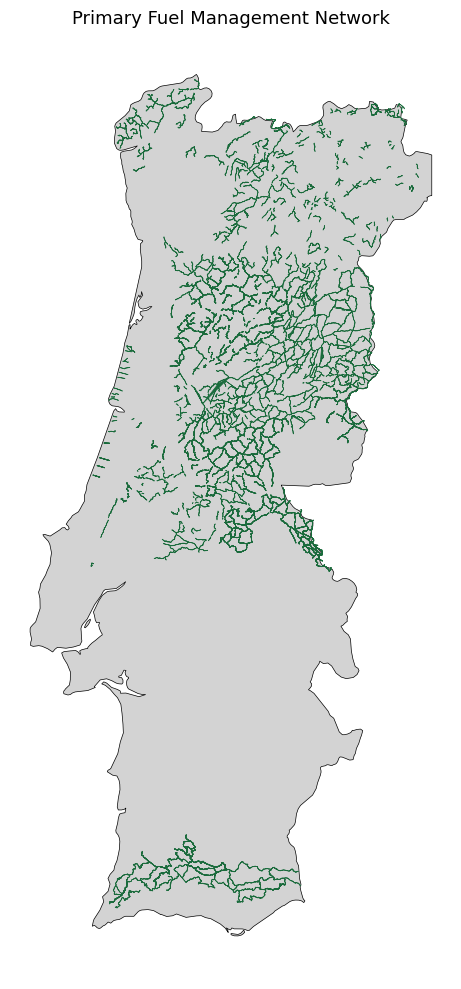

In [19]:
fig, ax = plt.subplots(figsize=(8, 10))
portugal_mainland.plot(ax=ax, color="lightgrey", edgecolor="black", linewidth=0.5)
fuel_network.plot(ax=ax, color="#1a6b3c", edgecolor="#1a6b3c", linewidth=0.5, alpha=1)
ax.set_title("Primary Fuel Management Network", fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("../outputs/fuel_network.png", dpi=150)
plt.show()

### 3.10 Classify and Visualise the Wildfire Risk Map
We classify the continuous risk values into five equal interval categories 
and plot the final national wildfire risk map.

Category counts:
  Class 1 : 1,297,235 pixels (50.0%)
  Class 2 : 699,722 pixels (27.0%)
  Class 3 : 528,068 pixels (20.4%)
  Class 4 : 63,447 pixels (2.4%)
  Class 5 : 5,778 pixels (0.2%)


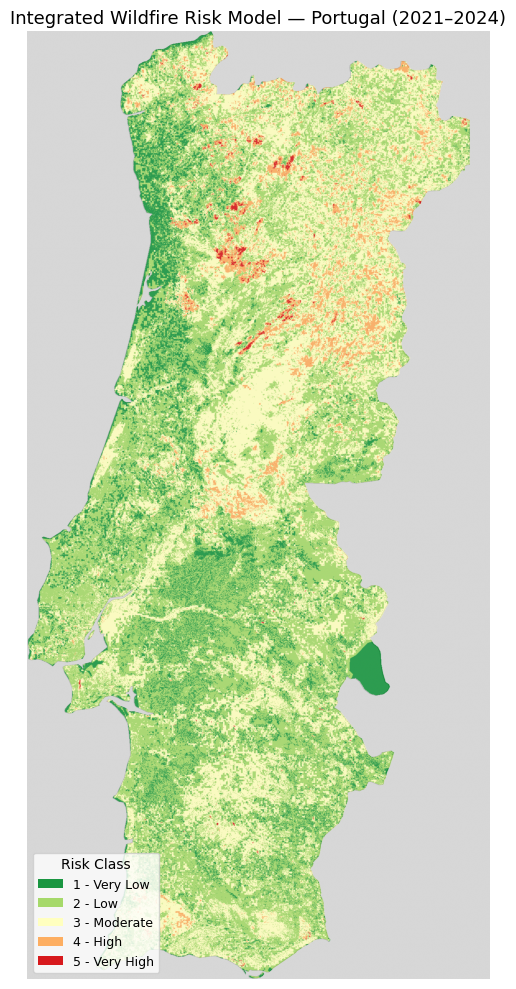

In [20]:
# Define colour map and legend
colors_risk = ["#1a9641", "#a6d96a", "#ffffbf", "#fdae61", "#d7191c"]
cmap_risk = LinearSegmentedColormap.from_list("risk", colors_risk, N=5)
cmap_risk.set_bad(color="lightgrey")

legend_elements = [
    Patch(facecolor="#1a9641", label="1 - Very Low"),
    Patch(facecolor="#a6d96a", label="2 - Low"),
    Patch(facecolor="#ffffbf", label="3 - Moderate"),
    Patch(facecolor="#fdae61", label="4 - High"),
    Patch(facecolor="#d7191c", label="5 - Very High"),
]

# Equal interval classification into 5 classes
risk_min = np.nanmin(risk_model)
risk_max = np.nanmax(risk_model)
interval = (risk_max - risk_min) / 5

risk_classified = np.where(
    ~np.isnan(risk_model),
    np.clip(np.ceil((risk_model - risk_min) / interval), 1, 5),
    np.nan
)

# Print distribution
print("Category counts:")
total = np.sum(~np.isnan(risk_classified))
for cat in [1, 2, 3, 4, 5]:
    count = np.sum(risk_classified == cat)
    print(f"  Class {int(cat)} : {count:,} pixels ({count/total*100:.1f}%)")

# Mask to Portugal boundary
from rasterio.features import geometry_mask
port_mask = geometry_mask(
    portugal_geom,
    out_shape=ref_shape,
    transform=ref_transform,
    invert=True
)
risk_display = np.where(port_mask, risk_classified, np.nan)

# Plot
fig, ax = plt.subplots(figsize=(8, 10))
portugal_mainland.plot(ax=ax, color="lightgrey", edgecolor="black", linewidth=0.5, zorder=1)
show(risk_display, transform=ref_transform, ax=ax, cmap=cmap_risk,
     vmin=1, vmax=5, zorder=2, alpha=0.9)
ax.legend(handles=legend_elements, loc="lower left", fontsize=9, title="Risk Class")
ax.set_title("Integrated Wildfire Risk Model — Portugal (2021–2024)", fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("../outputs/wildfire_risk_map.png", dpi=150)
plt.show()

## 4. Coverage Gap Analysis
### 4.1 Extract High Risk Zones
As the research question focuses on how well the fuel management network 
covers the highest risk areas, we extract only the cells classified as 
class 4 (High) and class 5 (Very High) risk. These areas form the basis 
of all subsequent coverage analysis.

Area by risk class:
  Class 1: 81,077.2 km2
  Class 2: 43,732.6 km2
  Class 3: 33,004.2 km2
  Class 4: 3,965.4 km2
  Class 5: 361.1 km2

Total high risk area (class 4+5): 4,326.6 km2


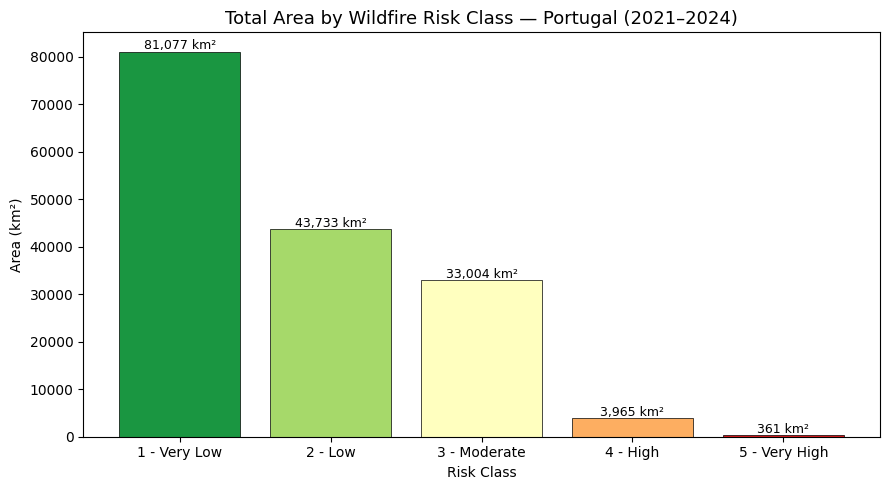

In [21]:
# Extract high risk pixels (class 4 and 5)
high_risk_mask = (risk_classified >= 4) & (~np.isnan(risk_classified))

# Calculate area per risk class
pixel_area_km2 = (250 * 250) / 1e6  # each pixel is 250m x 250m = 0.0625 km2

print("Area by risk class:")
total_valid = 0
for cat in [1, 2, 3, 4, 5]:
    count = np.sum(risk_classified == cat)
    area = count * pixel_area_km2
    total_valid += count
    print(f"  Class {int(cat)}: {area:,.1f} km2")

high_risk_area = np.sum(high_risk_mask) * pixel_area_km2
print(f"\nTotal high risk area (class 4+5): {high_risk_area:,.1f} km2")

# Bar chart
categories = [1, 2, 3, 4, 5]
labels = ["1 - Very Low", "2 - Low", "3 - Moderate", "4 - High", "5 - Very High"]
areas = [np.sum(risk_classified == cat) * pixel_area_km2 for cat in categories]
bar_colors = ["#1a9641", "#a6d96a", "#ffffbf", "#fdae61", "#d7191c"]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(labels, areas, color=bar_colors, edgecolor="black", linewidth=0.5)
for bar, area in zip(bars, areas):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f"{area:,.0f} km²", ha="center", fontsize=9)
ax.set_title("Total Area by Wildfire Risk Class — Portugal (2021–2024)", fontsize=13)
ax.set_xlabel("Risk Class")
ax.set_ylabel("Area (km²)")
plt.tight_layout()
plt.savefig("../outputs/area_by_risk_class.png", dpi=150)
plt.show()

### 4.2 Create Buffer Around Fuel Management Network
To evaluate whether a high risk area is covered by prevention infrastructure, 
we create buffer zones around the primary fuel management network at three 
distances: 500m, 1km and 2km. If a high risk area falls within the buffer 
it is considered covered. We test three distances to assess the sensitivity 
of results to the buffer size choice.

In [22]:
from rasterio.features import rasterize
from shapely.geometry import mapping

# Rasterise fuel network first
fuel_raster = rasterize(
    [(geom, 1) for geom in fuel_network.geometry if geom is not None],
    out_shape=ref_shape,
    transform=ref_transform,
    fill=0,
    dtype="uint8"
)

print("Fuel network rasterised:", fuel_raster.shape)
print("Fuel pixels:", np.sum(fuel_raster == 1))

Fuel network rasterised: (2306, 1125)
Fuel pixels: 19000


In [23]:
from scipy.ndimage import binary_dilation

# At 250m resolution:
# 500m = 2 pixels, 1km = 4 pixels, 2km = 8 pixels
fuel_bool = fuel_raster == 1

buffer_500_raster  = binary_dilation(fuel_bool, iterations=2)
buffer_1000_raster = binary_dilation(fuel_bool, iterations=4)
buffer_2000_raster = binary_dilation(fuel_bool, iterations=8)

print("500m buffer pixels:", np.sum(buffer_500_raster))
print("1km buffer pixels:", np.sum(buffer_1000_raster))
print("2km buffer pixels:", np.sum(buffer_2000_raster))

500m buffer pixels: 122930
1km buffer pixels: 227568
2km buffer pixels: 394336


### 4.3 Calculate National Coverage Statistics
We calculate what proportion of the high risk area (class 4+5) falls 
within each buffer distance of the primary fuel management network. 
This directly answers the first part of our research question: how 
effectively does the infrastructure cover high risk zones?

In [24]:
# High risk mask (class 4+5)
high_risk_mask = (risk_classified >= 4) & (~np.isnan(risk_classified))
total_high_risk = np.sum(high_risk_mask)
pixel_area_km2 = (250 * 250) / 1e6

results = []
for name, buf in [("500m", buffer_500_raster), 
                   ("1km", buffer_1000_raster), 
                   ("2km", buffer_2000_raster)]:
    covered = np.sum(high_risk_mask & buf)
    uncovered = total_high_risk - covered
    coverage_pct = covered / total_high_risk * 100
    gap_pct = uncovered / total_high_risk * 100
    results.append({
        "Buffer": name,
        "Total High Risk (km²)": total_high_risk * pixel_area_km2,
        "Covered (km²)": covered * pixel_area_km2,
        "Uncovered (km²)": uncovered * pixel_area_km2,
        "Coverage (%)": round(coverage_pct, 1),
        "Gap (%)": round(gap_pct, 1)
    })

import pandas as pd
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

Buffer  Total High Risk (km²)  Covered (km²)  Uncovered (km²)  Coverage (%)  Gap (%)
  500m              4326.5625       940.0625        3386.5000          21.7     78.3
   1km              4326.5625      1670.7500        2655.8125          38.6     61.4
   2km              4326.5625      2660.5000        1666.0625          61.5     38.5


### 4.4 Visualise National Coverage — Stacked Bar Chart
We visualise the proportion of high risk area covered vs uncovered 
for each buffer distance.

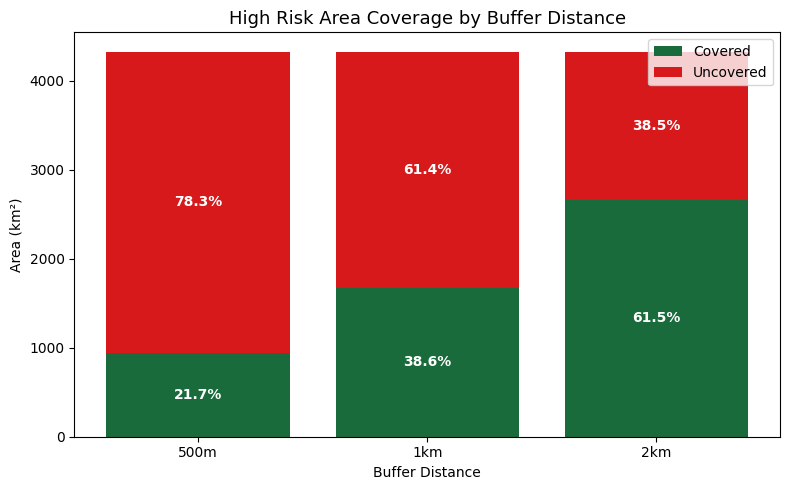

In [25]:
fig, ax = plt.subplots(figsize=(8, 5))

buffers = ["500m", "1km", "2km"]
covered = [940.06, 1670.75, 2660.50]
uncovered = [3386.50, 2655.81, 1666.06]

ax.bar(buffers, covered, color="#1a6b3c", label="Covered")
ax.bar(buffers, uncovered, bottom=covered, color="#d7191c", label="Uncovered")

for i, (c, u) in enumerate(zip(covered, uncovered)):
    total = c + u
    ax.text(i, c/2, f"{c/total*100:.1f}%", ha="center", va="center", 
            color="white", fontsize=10, fontweight="bold")
    ax.text(i, c + u/2, f"{u/total*100:.1f}%", ha="center", va="center",
            color="white", fontsize=10, fontweight="bold")

ax.set_title("High Risk Area Coverage by Buffer Distance", fontsize=13)
ax.set_xlabel("Buffer Distance")
ax.set_ylabel("Area (km²)")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig("../outputs/national_coverage_stacked.png", dpi=150)
plt.show()

### 4.5 Municipal Level Coverage Analysis
We calculate coverage statistics for each municipality using the 1km 
buffer as the primary analysis distance. For each municipality we compute 
the total high risk area, the covered portion, the uncovered portion and 
the gap ratio. This allows us to identify which municipalities have the 
greatest unmet prevention needs.

In [26]:
from rasterio.features import rasterize
import geopandas as gpd

# Reproject municipalities to match raster CRS (already EPSG:3763)
muni = municipalities.copy()

municipal_stats = []

for idx, row in muni.iterrows():
    geom = row.geometry
    name = row["NAME"]
    
    # Rasterise municipality boundary
    muni_mask = rasterize(
        [(geom, 1)],
        out_shape=ref_shape,
        transform=ref_transform,
        fill=0,
        dtype="uint8"
    ) == 1
    
    # High risk pixels in this municipality
    hr_pixels = np.sum(high_risk_mask & muni_mask)
    covered_pixels = np.sum(high_risk_mask & muni_mask & buffer_1000_raster)
    uncovered_pixels = hr_pixels - covered_pixels
    
    coverage_pct = (covered_pixels / hr_pixels * 100) if hr_pixels > 0 else np.nan
    gap_pct = (uncovered_pixels / hr_pixels * 100) if hr_pixels > 0 else np.nan
    
    municipal_stats.append({
        "Municipality": name,
        "High Risk Area (km²)": round(hr_pixels * pixel_area_km2, 2),
        "Covered (km²)": round(covered_pixels * pixel_area_km2, 2),
        "Uncovered (km²)": round(uncovered_pixels * pixel_area_km2, 2),
        "Coverage (%)": round(coverage_pct, 1),
        "Gap (%)": round(gap_pct, 1)
    })

municipal_df = pd.DataFrame(municipal_stats)
municipal_df = municipal_df.sort_values("Gap (%)", ascending=False)
print(municipal_df.head(10).to_string(index=False))

        Municipality  High Risk Area (km²)  Covered (km²)  Uncovered (km²)  Coverage (%)  Gap (%)
             Setúbal                  0.44            0.0             0.44           0.0    100.0
       Vila Do Bispo                  2.50            0.0             2.50           0.0    100.0
            Sesimbra                  3.88            0.0             3.88           0.0    100.0
               Moura                  1.38            0.0             1.38           0.0    100.0
               Lagoa                  0.12            0.0             0.12           0.0    100.0
              Mourão                  0.75            0.0             0.75           0.0    100.0
Ferreira Do Alentejo                  0.56            0.0             0.56           0.0    100.0
           Albufeira                  0.06            0.0             0.06           0.0    100.0
                Faro                  0.81            0.0             0.81           0.0    100.0
               Olhão

In [27]:
municipal_df = municipal_df.sort_values("Uncovered (km²)", ascending=False)

# Filter out municipalities with very small high risk area (less than 1 km²)
municipal_significant = municipal_df[municipal_df["High Risk Area (km²)"] >= 1.0]

print("Top 10 municipalities by uncovered high risk area:")
print(municipal_significant.head(10).to_string(index=False))

Top 10 municipalities by uncovered high risk area:
        Municipality  High Risk Area (km²)  Covered (km²)  Uncovered (km²)  Coverage (%)  Gap (%)
        Castro Daire                153.31          68.44            84.88          44.6     55.4
              Guarda                193.69         110.69            83.00          57.1     42.9
   Torre De Moncorvo                 95.44          17.06            78.38          17.9     82.1
          Montalegre                102.56          27.00            75.56          26.3     73.7
              Pinhel                108.50          42.81            65.69          39.5     60.5
            Bragança                100.06          35.12            64.94          35.1     64.9
Vila Nova De Foz Côa                 77.88          18.69            59.19          24.0     76.0
               Mação                118.06          59.06            59.00          50.0     50.0
    São Pedro Do Sul                112.12          56.88          

### 4.6 Visualise Municipal Coverage Gaps
We map the gap ratio per municipality and show the top 10 municipalities 
with the largest uncovered high risk areas to identify priority zones 
for prevention investment.

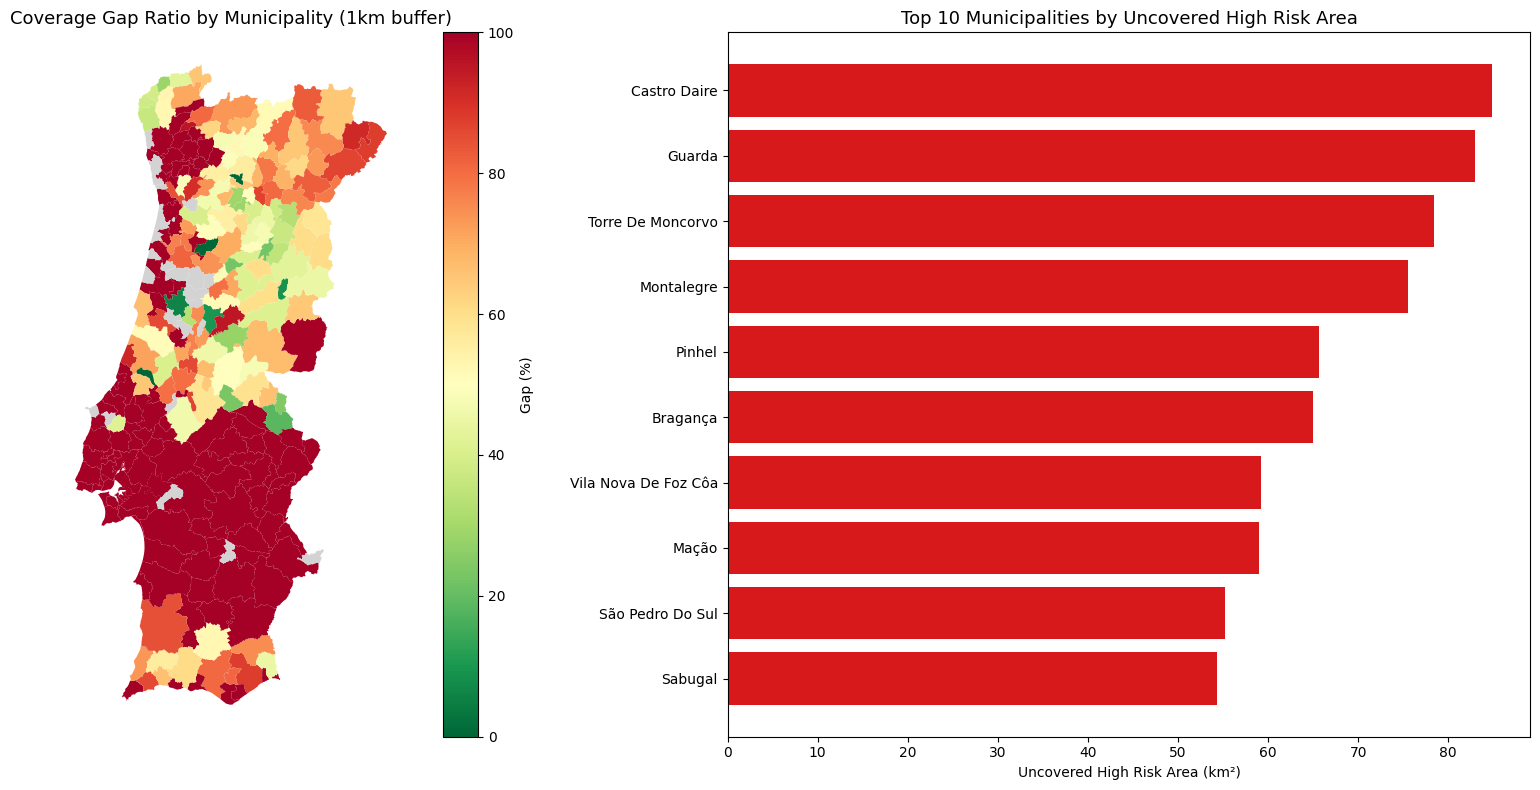

In [28]:
# Join stats back to municipality geodataframe
municipal_geo = municipalities.merge(municipal_df, left_on="NAME", right_on="Municipality", how="left")

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Map of gap ratio
municipal_geo.plot(ax=axes[0], column="Gap (%)", cmap="RdYlGn_r",
                   legend=True, missing_kwds={"color": "lightgrey"},
                   legend_kwds={"label": "Gap (%)"})
axes[0].set_title("Coverage Gap Ratio by Municipality (1km buffer)", fontsize=13)
axes[0].set_axis_off()

# Top 10 bar chart by uncovered area
top10 = municipal_significant.head(10)
axes[1].barh(top10["Municipality"], top10["Uncovered (km²)"], color="#d7191c")
axes[1].set_title("Top 10 Municipalities by Uncovered High Risk Area", fontsize=13)
axes[1].set_xlabel("Uncovered High Risk Area (km²)")
axes[1].invert_yaxis()
plt.tight_layout()
plt.savefig("../outputs/municipal_coverage_gaps.png", dpi=150)
plt.show()

### 4.7 Load Social Vulnerability Data
We use the INE 2023 Purchasing Power Index (PPC) per municipality as 
our social vulnerability indicator. Lower purchasing power indicates 
higher economic vulnerability. The data comes from INE's municipal 
purchasing power study (Estudo sobre o Poder de Compra Concelhio, 2023).

In [29]:
vuln_df = pd.read_csv("../data/raw/social_vulnerability/QD5.csv", 
                       encoding="latin1", sep=";", skiprows=3, header=None)
vuln_df.columns = ["Municipality", "IpC", "PPC", "FDR"]

# Convert to float
vuln_df["IpC"] = pd.to_numeric(vuln_df["IpC"].str.replace(",", "."), errors="coerce")
vuln_df["PPC"] = pd.to_numeric(vuln_df["PPC"].str.replace(",", "."), errors="coerce")
vuln_df["FDR"] = pd.to_numeric(vuln_df["FDR"].str.replace(",", "."), errors="coerce")

# Drop NaN rows
vuln_df = vuln_df.dropna(subset=["PPC"])
vuln_df["Municipality"] = vuln_df["Municipality"].str.strip()

# Keep only actual municipalities by matching with shapefile names
muni_names = municipalities["NAME"].str.strip().tolist()
vuln_muni = vuln_df[vuln_df["Municipality"].isin(muni_names)].copy()

print(f"Matched municipalities: {len(vuln_muni)} out of {len(muni_names)}")
print(vuln_muni.head(10))

Matched municipalities: 193 out of 281
   Municipality     IpC    PPC    FDR
5       Caminha   82.12  0.127  0.944
6       Melgaço   64.90  0.046  0.927
7        Monção   75.84  0.129  0.501
11      Valença   84.67  0.113  0.556
15       Amares   75.17  0.138 -0.040
16     Barcelos   82.15  0.903 -0.474
17        Braga  105.49  1.999 -0.525
18    Esposende   88.00  0.307  0.076
20   Vila Verde   75.64  0.342 -0.138
23         Fafe   76.90  0.351 -0.189


In [30]:
matched_names = vuln_muni["Municipality"].tolist()
unmatched = [name for name in muni_names if name not in matched_names]
print(f"Unmatched municipalities ({len(unmatched)}):")
for name in sorted(unmatched)[:20]:
    print(f"  '{name}'")

Unmatched municipalities (87):
  'Agueda'
  'Aguiar Da Beira'
  'Albergaria-A-Velha'
  'Alcacér Do Sal'
  'Alfândega Da Fé'
  'Alter Do Chão'
  'Arcos De Valdevez'
  'Arruda Dos Vinhos'
  'Cabeceiras De Basto'
  'Caldas Da Rainha'
  'Carrazeda De Ansiães'
  'Carregal Do Sal'
  'Castanheira De Pêra'
  'Castelo De Paiva'
  'Castelo De Vide'
  'Celorico Da Beira'
  'Celorico De Basto'
  'Condeixa-A-Nova'
  'Ferreira Do Alentejo'
  'Ferreira Do Zêzere'


In [31]:
# Normalise names for matching
import unicodedata

def normalise_name(name):
    """Lowercase and remove accents for fuzzy matching."""
    name = name.strip().lower()
    name = unicodedata.normalize("NFKD", name)
    name = "".join(c for c in name if not unicodedata.combining(c))
    return name

# Create normalised versions
vuln_df["name_norm"] = vuln_df["Municipality"].apply(normalise_name)
muni_norm = {normalise_name(n): n for n in muni_names}

# Match
vuln_df["matched_name"] = vuln_df["name_norm"].map(muni_norm)
vuln_muni = vuln_df.dropna(subset=["matched_name", "PPC"]).copy()

print(f"Matched municipalities: {len(vuln_muni)} out of {len(muni_names)}")
print(vuln_muni.head(5))

Matched municipalities: 278 out of 281
        Municipality    IpC    PPC    FDR          name_norm  \
4  Arcos de Valdevez  72.53  0.142  0.386  arcos de valdevez   
5            Caminha  82.12  0.127  0.944            caminha   
6            Melgaço  64.90  0.046  0.927            melgaco   
7             Monção  75.84  0.129  0.501             moncao   
8   Paredes de Coura  69.78  0.057 -0.141   paredes de coura   

        matched_name  
4  Arcos De Valdevez  
5            Caminha  
6            Melgaço  
7             Monção  
8   Paredes De Coura  


### 4.8 Create Social Vulnerability Score
We use the per capita income index (IpC) from INE 2023 as our vulnerability 
indicator. Portugal's national average is 100. Municipalities below 100 have 
lower than average purchasing power and are considered more vulnerable.
We invert and normalise the index to a 0-1 scale where 1 = most vulnerable.

In [32]:
# Use IpC — invert so higher score = more vulnerable
vuln_muni = vuln_muni.copy()
vuln_muni["vulnerability"] = 1 - (
    (vuln_muni["IpC"] - vuln_muni["IpC"].min()) /
    (vuln_muni["IpC"].max() - vuln_muni["IpC"].min())
)

# Join to municipality geodataframe using matched_name
vuln_geo = municipalities.merge(
    vuln_muni[["matched_name", "IpC", "PPC", "vulnerability"]],
    left_on="NAME", right_on="matched_name", how="left"
)

print(f"Municipalities with vulnerability score: {vuln_geo['vulnerability'].notna().sum()}")
print(vuln_geo[["NAME", "IpC", "vulnerability"]].sort_values("vulnerability", ascending=False).head(10))

Municipalities with vulnerability score: 281
                         NAME    IpC  vulnerability
187                   Tabuaço  63.53       1.000000
274                 Penamacor  63.77       0.997963
117                   Vimioso  63.80       0.997708
118                   Vinhais  64.26       0.993804
264                     Baião  64.54       0.991428
266               Sernancelhe  64.72       0.989900
107                   Melgaço  64.90       0.988372
81                   Valpaços  64.93       0.988117
189  Santa Marta De Penaguião  65.00       0.987523
72          Celorico De Basto  65.08       0.986844


### 4.9 Visualise Social Vulnerability
We map the vulnerability score per municipality. Darker colours indicate 
higher vulnerability (lower per capita income relative to national average).

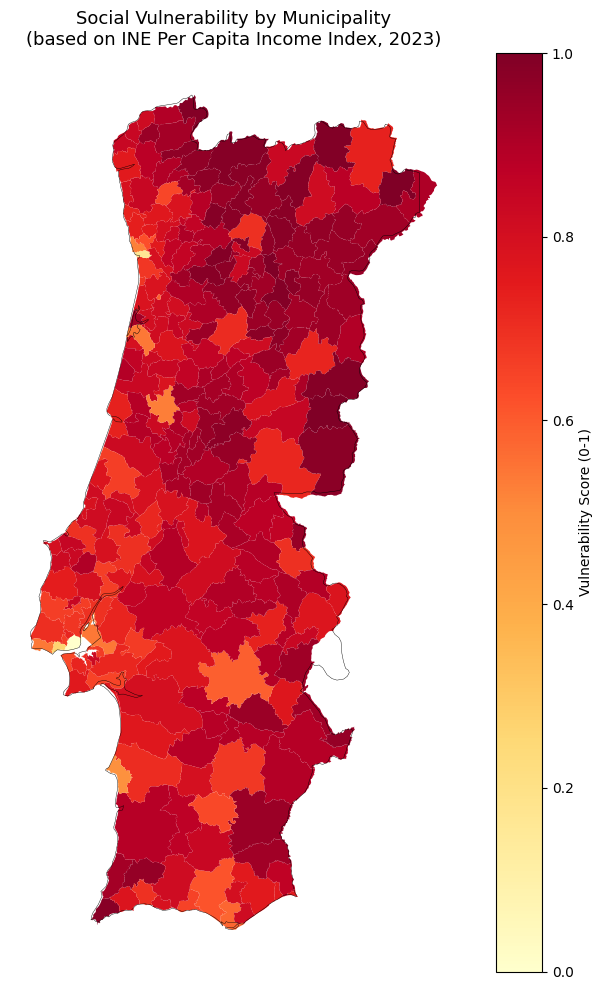

In [33]:
fig, ax = plt.subplots(figsize=(8, 10))
vuln_geo.plot(ax=ax, column="vulnerability", cmap="YlOrRd",
              legend=True, missing_kwds={"color": "lightgrey"},
              legend_kwds={"label": "Vulnerability Score (0-1)"})
portugal_mainland.plot(ax=ax, color="none", edgecolor="black", linewidth=0.3)
ax.set_title("Social Vulnerability by Municipality\n(based on INE Per Capita Income Index, 2023)", fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("../outputs/vulnerability_map.png", dpi=150)
plt.show()

## 5. Inequality Analysis
### 5.1 Combine Coverage Gaps and Vulnerability
We join the municipal coverage gap statistics with the vulnerability scores 
to test whether municipalities with higher social vulnerability also face 
greater gaps in wildfire prevention coverage — the core of our inequality argument.

In [34]:
# Join municipal stats with vulnerability
analysis_df = municipal_geo.merge(
    vuln_geo[["NAME", "IpC", "vulnerability"]],
    on="NAME", how="left"
)

# Drop municipalities with no high risk area
analysis_df = analysis_df[analysis_df["High Risk Area (km²)"] > 0].copy()

print(f"Municipalities with high risk area: {len(analysis_df)}")
print(analysis_df[["NAME", "High Risk Area (km²)", "Gap (%)", "vulnerability"]].head(10))

Municipalities with high risk area: 272
            NAME  High Risk Area (km²)  Gap (%)  vulnerability
0        Setúbal                  0.44    100.0       0.650569
1  Vila Do Bispo                  2.50    100.0       0.980479
2       Sesimbra                  3.88    100.0       0.759803
3          Moura                  1.38    100.0       0.888304
4         Tavira                  9.50     87.5       0.754371
5          Loulé                  6.81     80.7       0.617128
6         Mourão                  0.75    100.0       0.932100
7          Lagos                  1.75     85.7       0.776269
8          Lagoa                  0.12    100.0       0.788236
9           Faro                  0.81    100.0       0.577661


### 5.2 Scatter Plot — Vulnerability vs Coverage Gap
The scatter plot directly answers our research question: are coverage gaps 
disproportionately concentrated in the most socially vulnerable municipalities? 
Each point represents one municipality. A positive trend would indicate 
that more vulnerable municipalities tend to have larger coverage gaps.

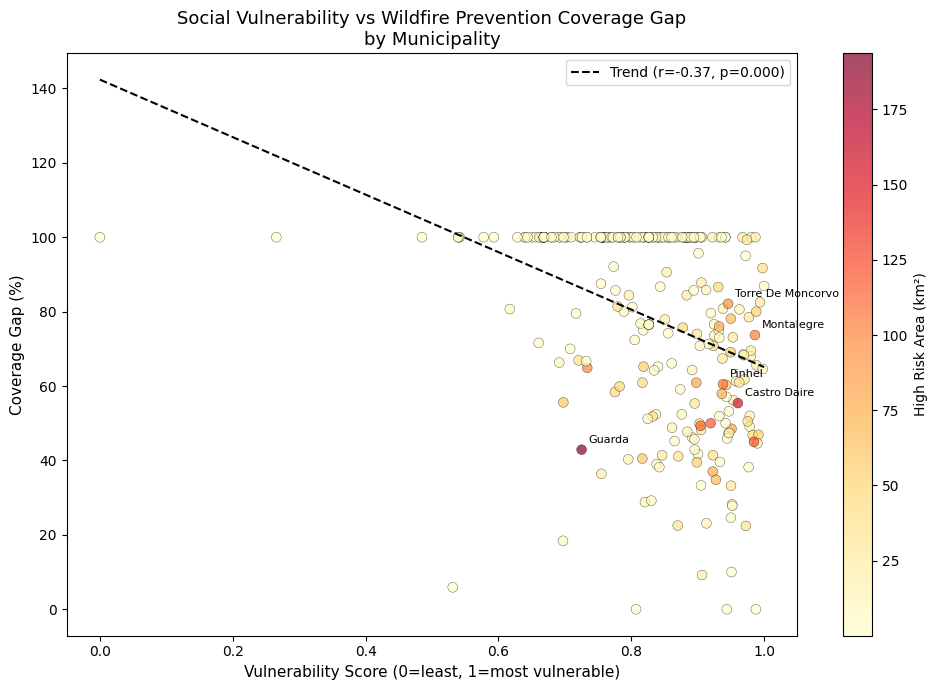


Correlation: r=-0.368, p-value=0.0000


In [35]:
from scipy import stats

# Drop rows with missing values
scatter_df = analysis_df.dropna(subset=["Gap (%)", "vulnerability"])

# Scatter plot
fig, ax = plt.subplots(figsize=(10, 7))

scatter = ax.scatter(
    scatter_df["vulnerability"],
    scatter_df["Gap (%)"],
    c=scatter_df["High Risk Area (km²)"],
    cmap="YlOrRd",
    alpha=0.7,
    edgecolors="black",
    linewidth=0.3,
    s=50
)

# Trend line
slope, intercept, r, p, se = stats.linregress(
    scatter_df["vulnerability"], scatter_df["Gap (%)"]
)
x_line = np.linspace(scatter_df["vulnerability"].min(), scatter_df["vulnerability"].max(), 100)
ax.plot(x_line, slope * x_line + intercept, color="black", linewidth=1.5, linestyle="--", label=f"Trend (r={r:.2f}, p={p:.3f})")

# Label top 5 most critical municipalities
top5 = scatter_df.nlargest(5, "Uncovered (km²)")
for _, row in top5.iterrows():
    ax.annotate(row["NAME"], (row["vulnerability"], row["Gap (%)"]),
                fontsize=8, xytext=(5, 5), textcoords="offset points")

plt.colorbar(scatter, ax=ax, label="High Risk Area (km²)")
ax.set_xlabel("Vulnerability Score (0=least, 1=most vulnerable)", fontsize=11)
ax.set_ylabel("Coverage Gap (%)", fontsize=11)
ax.set_title("Social Vulnerability vs Wildfire Prevention Coverage Gap\nby Municipality", fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("../outputs/scatter_vulnerability_gap.png", dpi=150)
plt.show()

print(f"\nCorrelation: r={r:.3f}, p-value={p:.4f}")

### 5.2 Interpretation of Scatter Plot Results
The scatter plot reveals a statistically significant negative correlation 
(r = -0.37, p < 0.001) between vulnerability and coverage gap. Contrary 
to what a simple inequality hypothesis would predict, more vulnerable 
municipalities do not systematically face larger coverage gaps. This is 
because the primary fuel management network is concentrated in the northern 
and central interior — precisely where both fire risk and vulnerability are 
highest — suggesting that network placement is broadly risk-informed.

However, this does not mean the situation is equitable. The municipalities 
with the largest absolute uncovered high risk areas (Castro Daire, Guarda, 
Torre de Moncorvo, Montalegre, Bragança) are all highly vulnerable interior 
municipalities. The relative coverage may be better than expected, but the 
sheer scale of unprotected territory in these areas — combined with their 
elderly, isolated and economically marginalised populations — represents a 
significant territorial inequality. A municipality with 80 km² of uncovered 
high risk area and a vulnerability score of 0.98 faces a very different 
challenge than a coastal municipality with 0.5 km² uncovered.

The inequality argument therefore shifts from "the network ignores vulnerable 
places" to "the network exists but is insufficient given the scale of risk 
and the limited capacity of vulnerable communities to self-protect."

### 5.3 Priority Classification
We classify each municipality into priority levels for policy intervention 
by combining their gap ratio and vulnerability score. Municipalities with 
both high coverage gaps and high vulnerability represent the most urgent 
cases for targeted prevention investment.

In [36]:
# Define priority based on gap and vulnerability thresholds
# Using median as threshold for each dimension
gap_threshold = scatter_df["Gap (%)"].median()
vuln_threshold = scatter_df["vulnerability"].median()

print(f"Gap threshold (median): {gap_threshold:.1f}%")
print(f"Vulnerability threshold (median): {vuln_threshold:.3f}")

def assign_priority(row):
    high_gap = row["Gap (%)"] >= gap_threshold
    high_vuln = row["vulnerability"] >= vuln_threshold
    high_risk = row["High Risk Area (km²)"] >= 10
    
    if high_gap and high_vuln and high_risk:
        return "Very High"
    elif high_gap and high_vuln:
        return "High"
    elif high_gap and not high_vuln:
        return "Medium"
    elif not high_gap and high_vuln:
        return "Low-Medium"
    else:
        return "Low"

scatter_df["Priority"] = scatter_df.apply(assign_priority, axis=1)

print("\nPriority distribution:")
print(scatter_df["Priority"].value_counts())

Gap threshold (median): 86.8%
Vulnerability threshold (median): 0.851

Priority distribution:
Priority
Medium        92
Low-Medium    92
Low           44
High          35
Very High      9
Name: count, dtype: int64


### 5.4 Priority Map
We map the priority classification to identify where targeted policy 
intervention is most urgently needed — municipalities combining high 
coverage gaps, high vulnerability and large high risk areas.

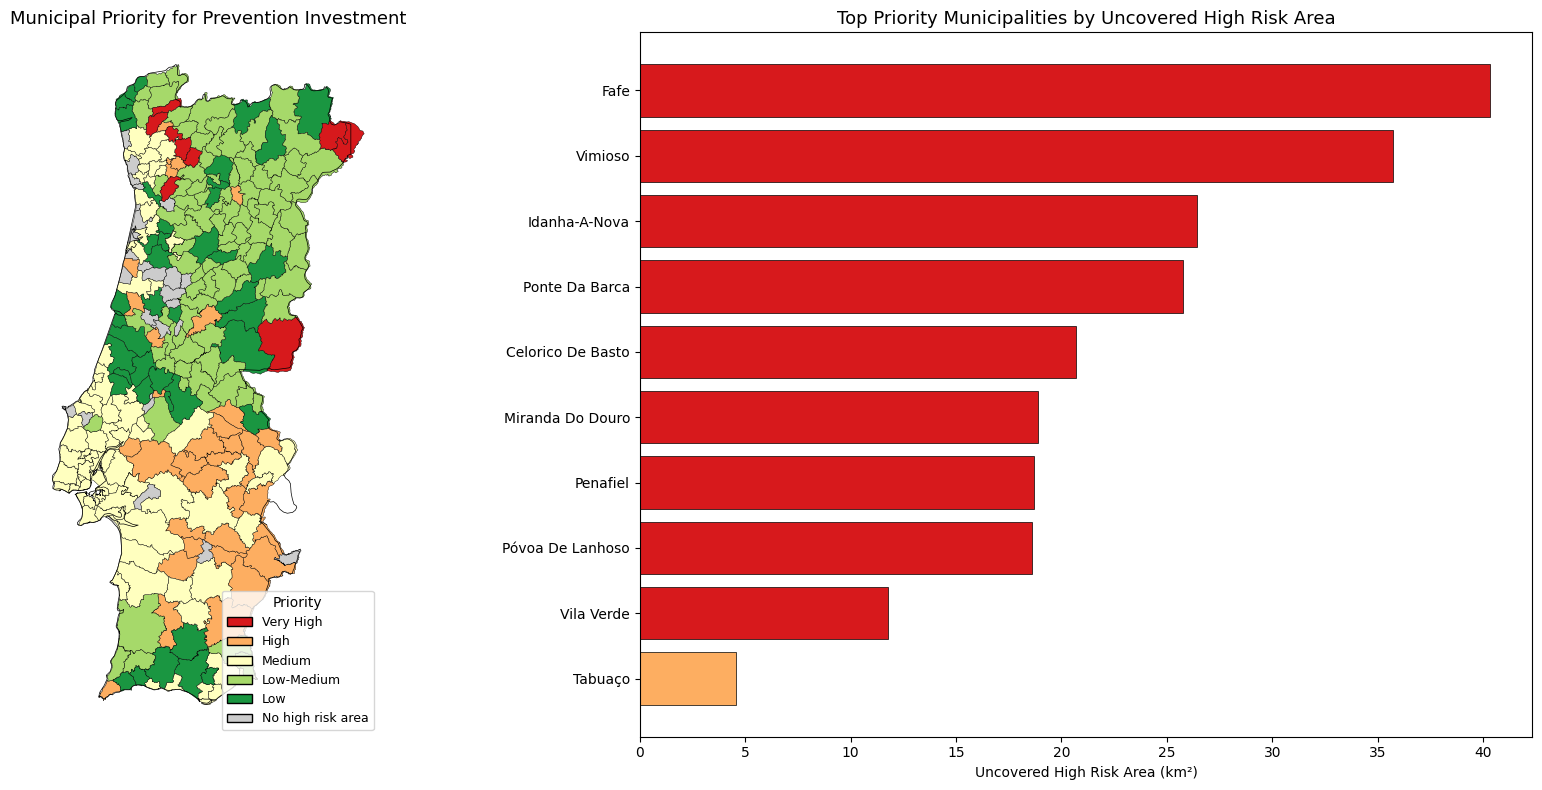

In [37]:
# Join priority back to geodataframe
priority_geo = municipalities.merge(
    scatter_df[["NAME", "Priority", "Gap (%)", "vulnerability", "High Risk Area (km²)"]],
    on="NAME", how="left"
)

# Define colour mapping
priority_colors = {
    "Very High": "#d7191c",
    "High": "#fdae61",
    "Medium": "#ffffbf",
    "Low-Medium": "#a6d96a",
    "Low": "#1a9641"
}

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Priority map
priority_geo["color"] = priority_geo["Priority"].map(priority_colors).fillna("#cccccc")
priority_geo.plot(ax=axes[0], color=priority_geo["color"], edgecolor="black", linewidth=0.3)
portugal_mainland.plot(ax=axes[0], color="none", edgecolor="black", linewidth=0.5)

legend_elements = [Patch(facecolor=c, edgecolor="black", label=p) 
                   for p, c in priority_colors.items()]
legend_elements.append(Patch(facecolor="#cccccc", edgecolor="black", label="No high risk area"))
axes[0].legend(handles=legend_elements, loc="lower right", 
               fontsize=9, title="Priority", bbox_to_anchor=(1.0, 0.0))
axes[0].set_title("Municipal Priority for Prevention Investment", fontsize=13)
axes[0].set_axis_off()

# Top priority bar chart
top_priority = scatter_df[scatter_df["Priority"].isin(["Very High", "High"])]\
    .sort_values("Uncovered (km²)", ascending=False).head(10)

colors_bar = [priority_colors[p] for p in top_priority["Priority"]]
axes[1].barh(top_priority["NAME"], top_priority["Uncovered (km²)"],
             color=colors_bar, edgecolor="black", linewidth=0.5)
axes[1].set_title("Top Priority Municipalities by Uncovered High Risk Area", fontsize=13)
axes[1].set_xlabel("Uncovered High Risk Area (km²)")
axes[1].invert_yaxis()
plt.tight_layout()
plt.savefig("../outputs/priority_map.png", dpi=150)
plt.show()

### 5.5 Correlation Heatmap
We compute a correlation matrix between the key municipal indicators: 
high risk area, coverage percentage, gap ratio and vulnerability score. 
This gives an overview of how these dimensions relate to each other.

In [38]:
import subprocess
import sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "seaborn"])

0

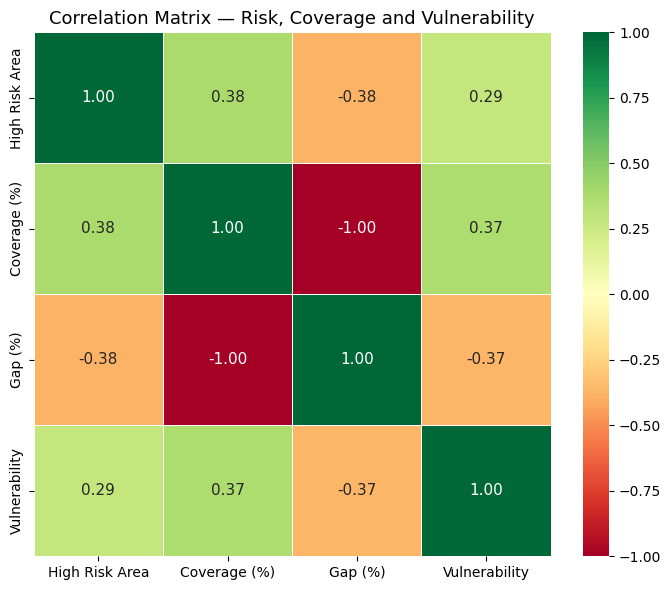

In [39]:
import seaborn as sns

corr_df = scatter_df[["High Risk Area (km²)", "Coverage (%)", "Gap (%)", "vulnerability"]].copy()
corr_df.columns = ["High Risk Area", "Coverage (%)", "Gap (%)", "Vulnerability"]

corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdYlGn",
            vmin=-1, vmax=1, ax=ax, linewidths=0.5,
            annot_kws={"size": 11})
ax.set_title("Correlation Matrix — Risk, Coverage and Vulnerability", fontsize=13)
plt.tight_layout()
plt.savefig("../outputs/correlation_heatmap.png", dpi=150)
plt.show()

### Interpretation of Correlation Heatmap
The correlation matrix confirms and extends the findings from the scatter plot:

- **Coverage (%) and Gap (%) show a perfect inverse correlation (-1.00)** — 
  this is expected since they are mathematical complements of each other.

- **High Risk Area and Coverage (%) show a moderate positive correlation (0.38)** — 
  municipalities with larger high risk areas tend to have better coverage. 
  This supports the idea that the fuel network was placed where fire risk is 
  highest, rather than randomly or based on other criteria.

- **Vulnerability and Coverage (%) show a moderate positive correlation (0.37)** — 
  more vulnerable municipalities tend to have slightly better coverage, 
  consistent with the scatter plot finding that the network broadly follows 
  risk patterns in the interior where vulnerability is also highest.

- **Vulnerability and Gap (%) show a moderate negative correlation (-0.37)** — 
  confirming that more vulnerable municipalities do not systematically face 
  larger gaps in relative terms.

Overall, the heatmap suggests that the primary fuel management network is 
broadly aligned with both fire risk and territorial vulnerability. However, 
as shown in the priority analysis, several highly vulnerable municipalities 
still have large absolute areas of uncovered high risk land, pointing to 
the need for targeted expansion of prevention infrastructure in these territories.